In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *

import pickle
import copy
import time
import humanfriendly

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import random
from torchmetrics.image import SpectralAngleMapper
from skimage.metrics import structural_similarity as ssim
import gc
import psutil
from multiprocessing import Pool
from scipy.optimize import nnls
from itertools import repeat
import matplotlib.patches as patches
from datetime import datetime


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import cv2
from scipy import ndimage

def upsample_interp23(image, ratio):

    image = np.transpose(image, (2, 0, 1))
    
    b,r,c = image.shape

    CDF23 = 2*np.array([0.5, 0.305334091185, 0, -0.072698593239, 0, 0.021809577942, 0, -0.005192756653, 0, 0.000807762146, 0, -0.000060081482])
    d = CDF23[::-1] 
    CDF23 = np.insert(CDF23, 0, d[:-1])
    BaseCoeff = CDF23
    
    first = 1
    for z in range(1,int(np.log2(ratio))+1):
        I1LRU = np.zeros((b, 2**z*r, 2**z*c))
        if first:
            I1LRU[:, 1:I1LRU.shape[1]:2, 1:I1LRU.shape[2]:2]=image
            first = 0
        else:
            I1LRU[:,0:I1LRU.shape[1]:2,0:I1LRU.shape[2]:2]=image
        
        for ii in range(0,b):
            t = I1LRU[ii,:,:]
            for j in range(0,t.shape[0]):
                t[j,:]=ndimage.correlate(t[j,:],BaseCoeff,mode='wrap')
            for k in range(0,t.shape[1]):
                t[:,k]=ndimage.correlate(t[:,k],BaseCoeff,mode='wrap')
            I1LRU[ii,:,:]=t
        image = I1LRU
        
    re_image=np.transpose(I1LRU, (1, 2, 0))
        
    return re_image

def estimation_alpha(pan, hs, mode='global'):
    if mode == 'global':
        IHC = np.reshape(pan, (-1, 1))
        ILRC = np.reshape(hs, (hs.shape[0]*hs.shape[1], hs.shape[2]))
        
        alpha = np.linalg.lstsq(ILRC, IHC)[0]
        
    elif mode == 'local':
        patch_size = 32
        all_alpha = []
        print(pan.shape)
        for i in range(0, hs.shape[0]-patch_size, patch_size):
            for j in range(0, hs.shape[1]-patch_size, patch_size):
                patch_pan = pan[i:i+patch_size, j:j+patch_size, :]
                patch_hs = hs[i:i+patch_size, j:j+patch_size, :]
                
                IHC = np.reshape(patch_pan, (-1, 1))
                ILRC = np.reshape(patch_hs, (-1, hs.shape[2]))
                
                local_alpha = np.linalg.lstsq(ILRC, IHC)[0]
                all_alpha.append(local_alpha)
                
        all_alpha = np.array(all_alpha)
        
        alpha = np.mean(all_alpha, axis=0, keepdims=False)
        
    return alpha

def GSA(pan, hs):
    
    M, N = pan.shape
    m, n, C = hs.shape
    
    ratio = int(np.round(M/m))
        
    print('get sharpening ratio: ', ratio)
    assert int(np.round(M/m)) == int(np.round(N/n))
    
    #upsample
    u_hs = upsample_interp23(hs, ratio)
    
    #remove means from u_hs
    means = np.mean(u_hs, axis=(0, 1))
    image_lr = u_hs-means
    
    #remove means from hs
    image_lr_lp = hs-np.mean(hs, axis=(0,1))
    
    #sintetic intensity
    image_hr = pan-np.mean(pan)
    image_hr0 = cv2.resize(image_hr, (n, m), cv2.INTER_CUBIC)
    image_hr0 = np.expand_dims(image_hr0, -1)
    
    alpha = estimation_alpha(image_hr0, np.concatenate((image_lr_lp, np.ones((m, n, 1))), axis=-1), mode='global')
    
    I = np.dot(np.concatenate((image_lr, np.ones((M, N, 1))), axis=-1), alpha)
    
    I0 = I-np.mean(I)
    
    #computing coefficients
    g = []
    g.append(1)
    
    for i in range(C):
        temp_h = image_lr[:, :, i]
        c = np.cov(np.reshape(I0, (-1,)), np.reshape(temp_h, (-1,)), ddof=1)
        g.append(c[0,1]/np.var(I0))
    g = np.array(g)
    
    #detail extraction
    delta = image_hr-I0
    deltam = np.tile(delta, (1, 1, C+1))
    
    #fusion
    V = np.concatenate((I0, image_lr), axis=-1)
    
    g = np.expand_dims(g, 0)
    g = np.expand_dims(g, 0)
    
    g = np.tile(g, (M, N, 1))
    
    V_hat = V + g*deltam
    
    I_GSA = V_hat[:, :, 1:]
    
    I_GSA = I_GSA - np.mean(I_GSA, axis=(0, 1)) + means
    
    #adjustment
    I_GSA[I_GSA<0]=0
    I_GSA[I_GSA>1]=1
    
    return I_GSA  #np.uint8(I_GSA*255)

### Load denoised datase

In [5]:
with open('../advanced_denoising/results/preprocessed_edx/20260218_120226_tile_aligned20frames_NGMeet.pkl', 'rb') as file:
    tile_NGMeet = pickle.load(file)


tile_NGMeet.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None
3,crop,"crop_idx=(slice(50, 1998, None), slice(50, 199...","(1948, 1948)","(1948, 1948, 250)",None
4,binning,"dim=(974, 974, 250)","(974, 974)","(974, 974, 250)",None
5,MeanFilterEDX,kernel_size=3,"(974, 974)","(974, 974, 250)",None
6,NGMeet_matlab,"sigma=0.3, nEM=10, nIter=2","(974, 974)","(974, 974, 250)",None


### Get the full resolution HAADF

In [6]:
# load and preprocess
file_path = "../data/EMD/EDXdataset.emd"
_, haadf_stack, _ = load_EDX(file_path, first_frame=0, last_frame=2, sum_frames=True, haadf_last_frame=False)

print(haadf_stack.shape)
haadf_fullres = haadf_stack[0,:,:]

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)


### Crop to match the EDX dataset and check dimensions

In [7]:
pad_remove = 50
haadf_fullres = haadf_fullres[pad_remove:2048-pad_remove,pad_remove:2048-pad_remove]
print('haadf shape, EDX shape: ', haadf_fullres.shape, tile_NGMeet.EDX_dim) 

haadf shape, EDX shape:  (1948, 1948) (974, 974, 250)


### Apply GSA

In [ ]:
edx_full_res = GSA(MinMax(haadf_fullres), MinMax(tile_NGMeet.EDX))

get sharpening ratio:  2


### Assign to object

In [34]:
# Assign to new tile object
tile_GSA = tile_NGMeet.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(None))},copy_instance=True)
tile_GSA.EDX = edx_full_res 

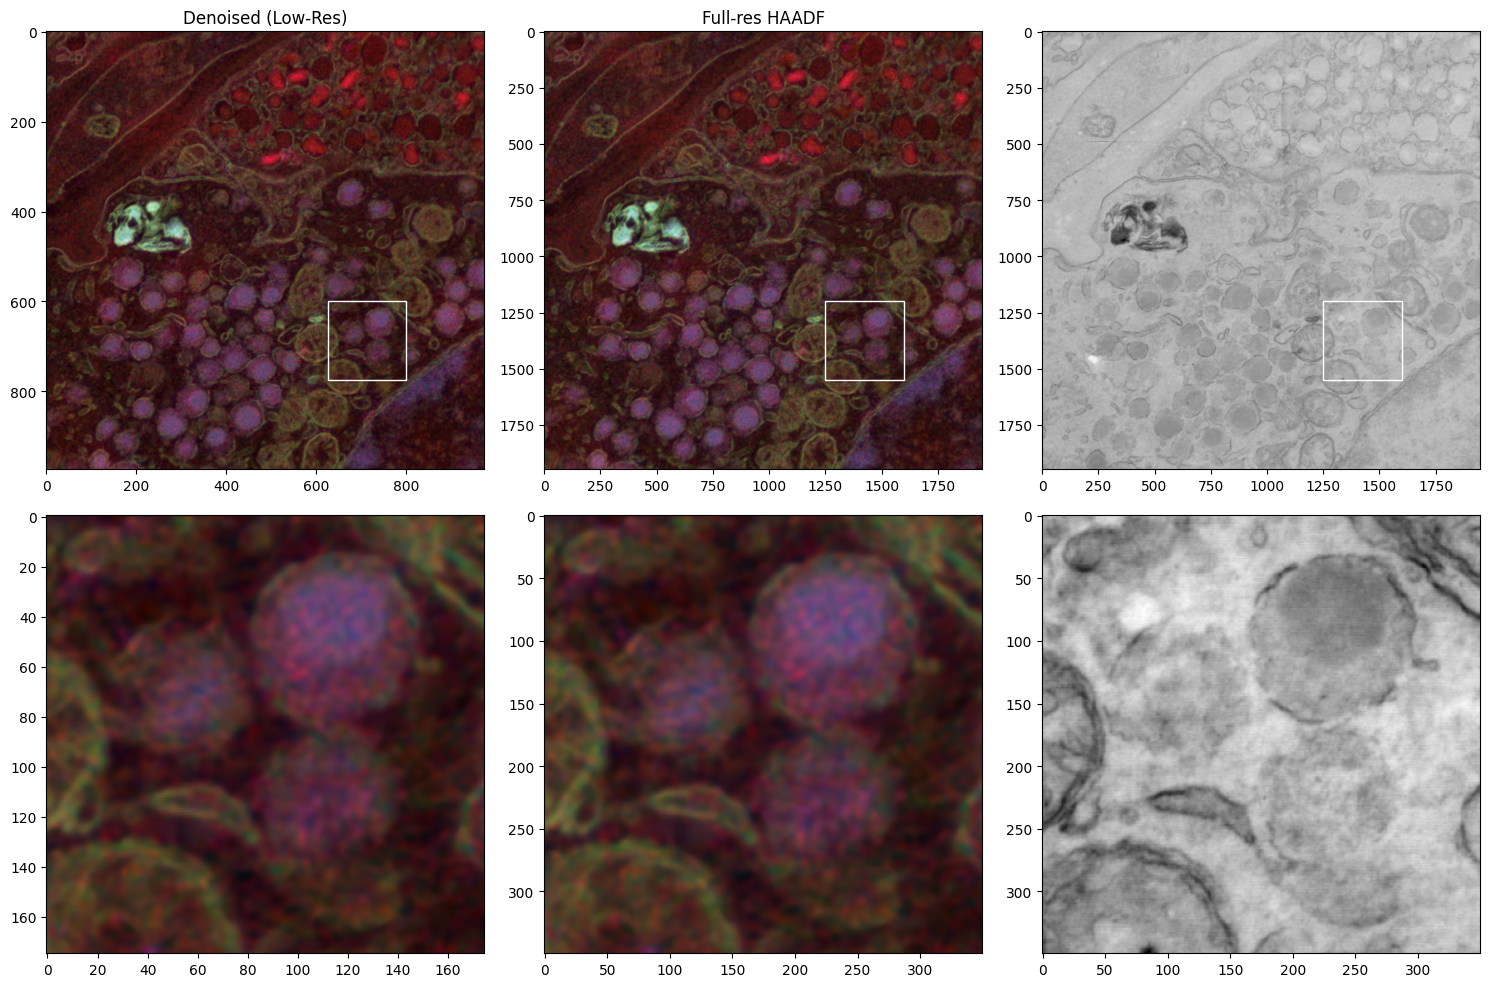

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Bands to display
bands = [4, 25, 28]
bands = [28,24,12]
#bands = [3,3,3]

img_lr = tile_NGMeet.FalseColor(bands)  
img_hr = tile_GSA.FalseColor(bands)   

# zoom (hr)
zoom_hr = (slice(1250, 1750), slice(1250, 1750))
zoom_hr = (slice(1200, 1550), slice(1250, 1600))

ys_hr, xs_hr = zoom_hr
y0_hr, y1_hr = ys_hr.start, ys_hr.stop
x0_hr, x1_hr = xs_hr.start, xs_hr.stop


# scale factor
scale_y = img_hr.shape[0] / img_lr.shape[0]
scale_x = img_hr.shape[1] / img_lr.shape[1]

# low-res zoom
zoom_lr = (
    slice(int(y0_hr / scale_y), int(y1_hr / scale_y)),
    slice(int(x0_hr / scale_x), int(x1_hr / scale_x)),
    slice(None)
)

ys_lr, xs_lr, _ = zoom_lr
y0_lr, y1_lr = ys_lr.start, ys_lr.stop
x0_lr, x1_lr = xs_lr.start, xs_lr.stop

# plot
f, ax = plt.subplots(2, 3, figsize=(15, 10))

# --- Full images ---
ax[0][0].imshow(img_lr)
ax[0][0].set_title('Denoised (Low-Res)')

ax[0][1].imshow(img_hr)
ax[0][1].set_title('Denoised + PS (High-Res)')

# haadf
ax[0][2].imshow(haadf_fullres, cmap='gray_r')
ax[0][2].set_title('Full-res HAADF')

# --- Zoomed regions ---
ax[1][0].imshow(img_lr[zoom_lr])


ax[1][1].imshow(img_hr[zoom_hr])


ax[1][2].imshow(haadf_fullres[zoom_hr],cmap='gray_r')



# Rectangle on low-res
ax[0][0].add_patch(
    patches.Rectangle(
        (x0_lr, y0_lr),
        x1_lr - x0_lr,
        y1_lr - y0_lr,
        linewidth=1,
        edgecolor='white',
        facecolor='none'
    )
)

# Rectangle on high-res
ax[0][1].add_patch(
    patches.Rectangle(
        (x0_hr, y0_hr),
        x1_hr - x0_hr,
        y1_hr - y0_hr,
        linewidth=1,
        edgecolor='white',
        facecolor='none'
    )
)


# Rectangle on haadf
ax[0][2].add_patch(
    patches.Rectangle(
        (x0_hr, y0_hr),
        x1_hr - x0_hr,
        y1_hr - y0_hr,
        linewidth=1,
        edgecolor='white',
        facecolor='none'
    )
)




#for axx in ax.ravel():
#    axx.axis('off')

plt.tight_layout()
plt.show()